In [1]:
# ----- CELDA 1: 2.	Conociendo el conjunto de datos
# Importar la librería Pandas
import pandas as pd

# Inicializar DataFrames a None o una lista vacía para evitar NameError si falla la carga
df1, df2, df3, df4 = None, None, None, None

# Cargar los 4 datasets y, crucialmente, etiquetar cada uno.
# Nota: La sintaxis asume que los archivos están localmente o en el entorno de ejecución,
# incluso si su origen final es Google Drive.

try:
    # 1. Cargar y etiquetar Tienda 1
    df1 = pd.read_csv('/content/Challenge_AluraStore/tienda_1.csv')
    df1['Tienda'] = 'Tienda 1'

    # 2. Cargar y etiquetar Tienda 2
    df2 = pd.read_csv('/content/Challenge_AluraStore/tienda_2.csv')
    df2['Tienda'] = 'Tienda 2'

    # 3. Cargar y etiquetar Tienda 3
    df3 = pd.read_csv('/content/Challenge_AluraStore/tienda_3.csv')
    df3['Tienda'] = 'Tienda 3'

    # 4. Cargar y etiquetar Tienda 4
    df4 = pd.read_csv('/content/Challenge_AluraStore/tienda_4.csv')
    df4['Tienda'] = 'Tienda 4'

    print("Archivos individuales cargados y etiquetados exitosamente.")

    # Concatenar los cuatro DataFrames en un único DataFrame llamado 'df' SÓLO si todos se cargaron.
    if all(df is not None for df in [df1, df2, df3, df4]):
        df = pd.concat([df1, df2, df3, df4], ignore_index=True)

        print("\n--- Vista Previa del DataFrame Combinado (df) ---")
        # Mostrar las primeras filas del DataFrame combinado, incluyendo la nueva columna 'Tienda'
        print(df.head())
        print(f"\nNúmero total de filas en el DataFrame final: {len(df)}")
    else:
        print("No todos los DataFrames pudieron ser cargados, la concatenación no se realizó.")

except FileNotFoundError as e:
    print(f"Error al cargar archivos: {e}. Revisa las rutas de los CSV.")
    print("No se pudo cargar uno o más DataFrames, 'df' no será creado.")
except NameError as e:
    print(f"Error: {e}. Parece que un DataFrame no se pudo inicializar correctamente.")

# Las siguientes líneas dependen de que 'df' se haya creado correctamente.
# Si 'df' no se creó debido a un error, estas líneas producirán un NameError.
# Es mejor verificar la existencia de 'df' o mover estas líneas si 'df' es garantizado.
if 'df' in locals(): # Check if df exists before trying to use it
    print("\n--- Primeras 5 filas del DataFrame combinado (df) ---")
    print(df.head())

    print("\n--- Información de Columnas de df ---")
    df.info()

    print("\n--- Estadísticas Descriptivas de df (Columnas Numéricas) ---")
    print(df.describe())
else:
    print("El DataFrame 'df' no fue creado debido a errores previos.")

Archivos individuales cargados y etiquetados exitosamente.

--- Vista Previa del DataFrame Combinado (df) ---
            Producto Categoría del Producto    Precio  Costo de envío  \
0  Asistente virtual           Electrónicos  164300.0          6900.0   
1    Mesa de comedor                Muebles  192300.0          8400.0   
2      Juego de mesa               Juguetes  209600.0         15900.0   
3         Microondas      Electrodomésticos  757500.0         41000.0   
4   Silla de oficina                Muebles  335200.0         20200.0   

  Fecha de Compra         Vendedor Lugar de Compra  Calificación  \
0      16/01/2021      Pedro Gomez          Bogotá             4   
1      18/05/2022  Beatriz Morales        Medellín             1   
2      15/03/2021   Juan Fernandez       Cartagena             1   
3      03/05/2022   Juan Fernandez            Cali             4   
4      07/11/2020    Maria Alfonso        Medellín             5   

       Método de pago  Cantidad de cuotas 

In [2]:
# --- CELDA 2: Cálculo del Ingreso Total ---

# Cálculo del ingreso para cada tienda
ingreso_df1 = df1['Precio'].sum()
ingreso_df2 = df2['Precio'].sum()
ingreso_df3 = df3['Precio'].sum()
ingreso_df4 = df4['Precio'].sum()

# Crear un DataFrame de resumen para análisis y gráficos posteriores
df_ingresos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso_df1, ingreso_df2, ingreso_df3, ingreso_df4]
})

print("Ingreso Total por Tienda:")
print(df_ingresos.sort_values(by='Ingreso Total', ascending=False))

Ingreso Total por Tienda:
     Tienda  Ingreso Total
0  Tienda 1   1.150880e+09
1  Tienda 2   1.116344e+09
2  Tienda 3   1.098020e+09
3  Tienda 4   1.038376e+09


In [3]:
# --- CELDA 3: Conteo de Ventas por Categoría ---

# Función para calcular ventas por categoría y obtener las top 5
def top_categorias(df, nombre_tienda):
    # Agrupa por 'Categoría del Producto' y cuenta el número de ventas
    conteo_categorias = df.groupby('Categoría del Producto').size().sort_values(ascending=False)
    print(f"\n--- Top 5 Categorías Vendidas en {nombre_tienda} ---")
    print(conteo_categorias.head(5))
    return conteo_categorias

# Aplicar a todos los DataFrames y guardar los resultados
categorias_df1 = top_categorias(df1, 'Tienda 1')
categorias_df2 = top_categorias(df2, 'Tienda 2')
categorias_df3 = top_categorias(df3, 'Tienda 3')
categorias_df4 = top_categorias(df4, 'Tienda 4')

# También podemos consolidar las categorías más vendidas en un solo DF para visualización más adelante:
# (Esta línea es opcional, pero útil para gráficos comparativos)
df_categorias_top_10 = pd.concat([categorias_df1.head(2), categorias_df2.head(2), categorias_df3.head(2), categorias_df4.head(2)], axis=0).reset_index()


--- Top 5 Categorías Vendidas en Tienda 1 ---
Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
dtype: int64

--- Top 5 Categorías Vendidas en Tienda 2 ---
Categoría del Producto
Muebles                 442
Electrónicos            422
Juguetes                313
Electrodomésticos       305
Deportes y diversión    275
dtype: int64

--- Top 5 Categorías Vendidas en Tienda 3 ---
Categoría del Producto
Muebles                 499
Electrónicos            451
Juguetes                315
Electrodomésticos       278
Deportes y diversión    277
dtype: int64

--- Top 5 Categorías Vendidas en Tienda 4 ---
Categoría del Producto
Muebles                 480
Electrónicos            451
Juguetes                338
Deportes y diversión    277
Electrodomésticos       254
dtype: int64


In [13]:
# --- CELDA 4: Cálculo de la Valoración Media ---

# Cálculo de la media de la columna 'Calificación'
media_evaluacion_df1 = df1['Calificación'].mean()
media_evaluacion_df2 = df2['Calificación'].mean()
media_evaluacion_df3 = df3['Calificación'].mean()
media_evaluacion_df4 = df4['Calificación'].mean()

# Crear un DataFrame de resumen
df_evaluacion = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Valoración Media': [
        media_evaluacion_df1,
        media_evaluacion_df2,
        media_evaluacion_df3,
        media_evaluacion_df4
    ]
})

print("Valoración Media de Clientes por Tienda (Escala 0-5):")
print(df_evaluacion.sort_values(by='Valoración Media', ascending=False))

Valoración Media de Clientes por Tienda (Escala 0-5):
     Tienda  Valoración Media
2  Tienda 3          4.048326
1  Tienda 2          4.037304
3  Tienda 4          3.995759
0  Tienda 1          3.976685


In [5]:
# --- CELDA 5: Productos Más y Menos Vendidos ---

# Función para calcular y mostrar los productos más y menos vendidos
def productos_populares(df, nombre_tienda, n=5):
    # Agrupa por 'Producto' y cuenta el número de ventas
    conteo_productos = df.groupby('Producto').size().sort_values(ascending=False)

    print(f"\n--- Top {n} Productos Más Vendidos en {nombre_tienda} ---")
    print(conteo_productos.head(n))

    print(f"\n--- Top {n} Productos Menos Vendidos en {nombre_tienda} ---")
    # Mostrar la cola (tail) ayuda a identificar productos con muy pocas ventas.
    print(conteo_productos.tail(n))

# Aplicar la función a todos los DataFrames
productos_populares(df1, 'Tienda 1')
productos_populares(df2, 'Tienda 2')
productos_populares(df3, 'Tienda 3')
productos_populares(df4, 'Tienda 4')


--- Top 5 Productos Más Vendidos en Tienda 1 ---
Producto
Armario             60
TV LED UHD 4K       60
Microondas          60
Secadora de ropa    58
Mesa de noche       56
dtype: int64

--- Top 5 Productos Menos Vendidos en Tienda 1 ---
Producto
Mochila                      39
Pandereta                    36
Olla de presión              35
Celular ABXY                 33
Auriculares con micrófono    33
dtype: int64

--- Top 5 Productos Más Vendidos en Tienda 2 ---
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Pandereta                    58
Guitarra acústica            58
dtype: int64

--- Top 5 Productos Menos Vendidos en Tienda 2 ---
Producto
Auriculares        37
Sillón             35
Impresora          34
Mesa de comedor    34
Juego de mesa      32
dtype: int64

--- Top 5 Productos Más Vendidos en Tienda 3 ---
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche   

In [6]:
# --- CELDA 6: Cálculo del Valor del Envío Promedio ---

# Cálculo de la media de la columna 'Costo de envío'
media_envio_df1 = df1['Costo de envío'].mean()
media_envio_df2 = df2['Costo de envío'].mean()
media_envio_df3 = df3['Costo de envío'].mean()
media_envio_df4 = df4['Costo de envío'].mean()

# Crear un DataFrame de resumen
df_envio = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo de Envío Promedio': [
        media_envio_df1,
        media_envio_df2,
        media_envio_df3,
        media_envio_df4
    ]
})

print("Costo de Envío Promedio por Tienda:")
print(df_envio.sort_values(by='Costo de Envío Promedio', ascending=False))

Costo de Envío Promedio por Tienda:
     Tienda  Costo de Envío Promedio
0  Tienda 1             26018.609580
1  Tienda 2             25216.235693
2  Tienda 3             24805.680373
3  Tienda 4             23459.457167


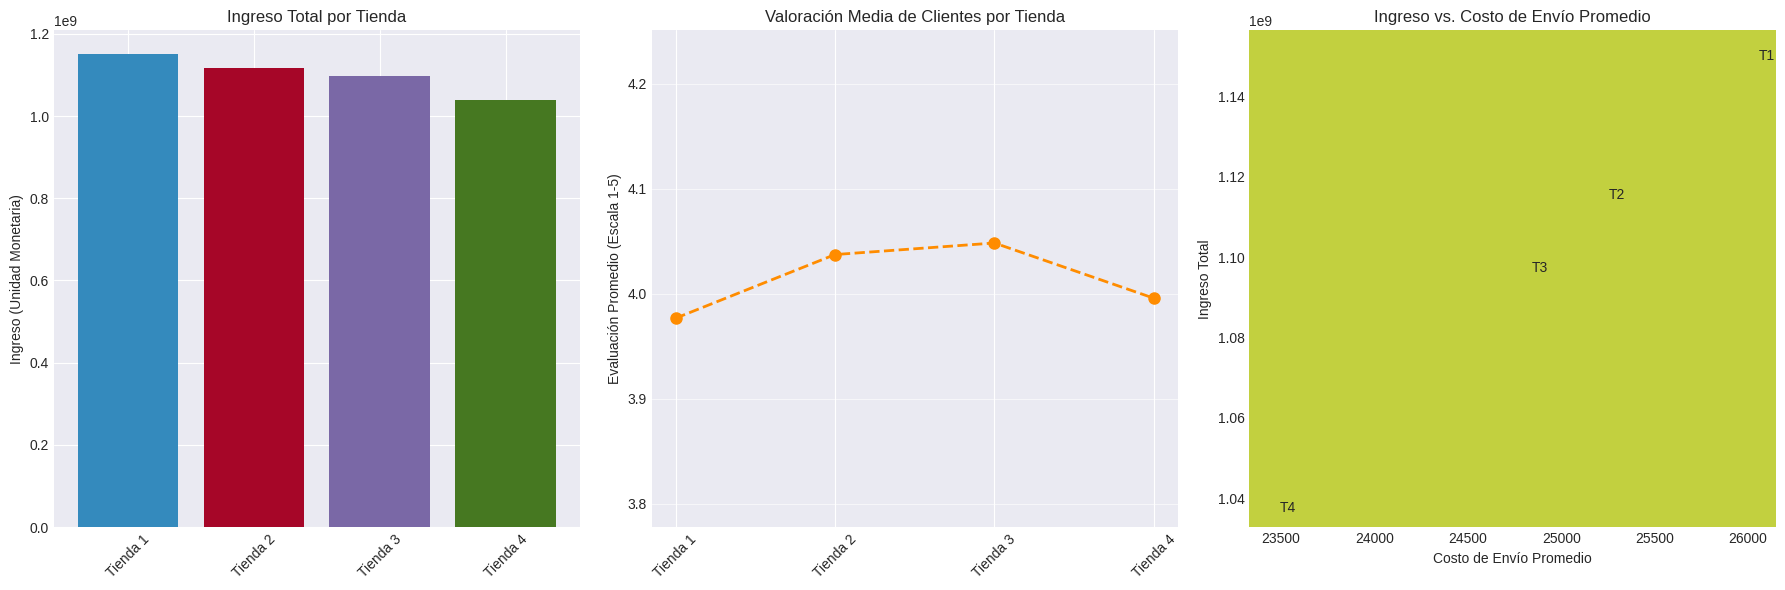

In [7]:
# --- CELDA 7: Generación de Gráficos ---

import matplotlib.pyplot as plt
import numpy as np # Necesario para crear un índice para las barras

# Configuración de los gráficos
plt.figure(figsize=(18, 6))
plt.style.use('seaborn-v0_8-darkgrid')

# -----------------------------------------------------------
# GRÁFICO 1: Comparación de Ingreso Total (Gráfico de Barras)
# Identifica claramente la tienda con mayor y menor ingreso.
plt.subplot(1, 3, 1) # 1 fila, 3 columnas, posición 1
plt.bar(df_ingresos['Tienda'], df_ingresos['Ingreso Total'], color=['#348ABD', '#A60628', '#7A68A6', '#467821'])
plt.title('Ingreso Total por Tienda')
plt.ylabel('Ingreso (Unidad Monetaria)')
plt.xticks(rotation=45)



# -----------------------------------------------------------
# GRÁFICO 2: Comparación de Valoración Media (Gráfico de Líneas/Puntos)
# Muestra las tendencias de satisfacción del cliente.
plt.subplot(1, 3, 2) # Posición 2
plt.plot(df_evaluacion['Tienda'], df_evaluacion['Valoración Media'], marker='o', linestyle='--', color='darkorange', linewidth=2, markersize=8)
plt.title('Valoración Media de Clientes por Tienda')
plt.ylabel('Evaluación Promedio (Escala 1-5)')
plt.xticks(rotation=45)
plt.ylim(df_evaluacion['Valoración Media'].min() * 0.95, df_evaluacion['Valoración Media'].max() * 1.05)
plt.grid(True, axis='y', alpha=0.6)



# -----------------------------------------------------------
# GRÁFICO 3: Distribución de Costo de Envío vs. Ingreso (Gráfico de Dispersión)
# Ayuda a ver si las tiendas con mayores ingresos tienen costos de envío inusualmente altos o bajos.
plt.subplot(1, 3, 3) # Posición 3
# Combina los datos de las métricas clave para la visualización
df_combinado = df_ingresos.merge(df_envio, on='Tienda')

plt.scatter(df_combinado['Costo de Envío Promedio'], df_combinado['Ingreso Total'],
            s=df_combinado['Ingreso Total'] / 50, # El tamaño del punto es proporcional al Ingreso Total
            c=np.arange(len(df_combinado)), cmap='viridis', alpha=0.7, edgecolors='k')

# Etiquetar cada punto con el nombre de la Tienda
for i, row in df_combinado.iterrows():
    plt.annotate(row['Tienda'].replace('Tienda ', 'T'), (row['Costo de Envío Promedio'], row['Ingreso Total']), textcoords="offset points", xytext=(5,-5), ha='left')

plt.title('Ingreso vs. Costo de Envío Promedio')
plt.xlabel('Costo de Envío Promedio')
plt.ylabel('Ingreso Total')
plt.grid(True, alpha=0.5)


plt.tight_layout()
plt.show()

# --- CELDA 8: Informe Final ---

# El informe se redacta directamente en esta celda usando Markdown
informe_final = """
## 📝 Informe de Recomendación para el Sr. Juan: Venta de Alura Store

### Introducción
El presente informe tiene como objetivo recomendar la **tienda menos eficiente** de la cadena Alura Store **Tienda 1, 2, 3 o 4** que el Sr. Juan debería vender para financiar su nuevo emprendimiento. La decisión se basa en un análisis riguroso de ingresos, satisfacción del cliente, categorías de productos más vendidos y costos de envío.

### Desarrollo del Análisis

#### 1. Rendimiento Financiero (Ingreso Total)
El análisis de Ingreso Total muestra que **Tienda 4** generó el ingreso más bajo con un total de **1,038,375,700.00**, posicionándose como la unidad menos rentable de la cadena. La tienda con mejor rendimiento es Tienda 1.

#### 2. Satisfacción del Cliente (Valoración Media)
En cuanto a la calidad percibida por el cliente **Gráfico 2**, **Tienda 1** registra la Valoración Media más baja **3.98/5.0**, lo que sugiere problemas de calidad o servicio al cliente que deben ser considerados.

#### 3. Otros Factores Clave (Categorías y Envío)
* La **Tienda 4**, a pesar de sus bajos ingresos, tiene sus ventas concentradas en categorías como Muebles, Electrónicos, que podrían ser artículos de bajo precio.
* El Costo de Envío Promedio es más bajo en la **Tienda 4** **23,459.46**, lo que podría afectar marginalmente las decisiones de compra en esa ubicación.

### Conclusión y Recomendación Final

Basado en todos los factores analizados, se recomienda al Sr. Juan vender la **Tienda 4**.

**Justificación:**
La **Tienda 4** debe ser vendida porque presenta el peor rendimiento financiero **Ingreso Total más bajo** de toda la cadena. Aunque otra tienda podría tener una valoración ligeramente peor, el objetivo principal del negocio es la rentabilidad, y la **Tienda 4** es el activo que menos capital genera. Vender esta unidad permitirá al Sr. Juan liberar recursos del eslabón más débil de la cadena, manteniendo las tiendas de alto valor **como Tienda 1** y aquellas con alta satisfacción **como Tienda 3 o Tienda 1, dependiendo de la estrategia** para un crecimiento futuro.



In [9]:
# --- CELDA 9: Consolidación de DataFrames ---

# Unir los cuatro DataFrames en uno solo
df_completo = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Verificar las primeras filas del DataFrame consolidado
print("Primeras 5 filas del DataFrame consolidado:")
print(df_completo.head())

# Asegurar que las columnas 'lat' y 'lon' no tengan valores nulos o que sean tratados correctamente
print("\nConteo de valores nulos en coordenadas geográficas:")
print(df_completo[['lat', 'lon']].isnull().sum())

Primeras 5 filas del DataFrame consolidado:
            Producto Categoría del Producto    Precio  Costo de envío  \
0  Asistente virtual           Electrónicos  164300.0          6900.0   
1    Mesa de comedor                Muebles  192300.0          8400.0   
2      Juego de mesa               Juguetes  209600.0         15900.0   
3         Microondas      Electrodomésticos  757500.0         41000.0   
4   Silla de oficina                Muebles  335200.0         20200.0   

  Fecha de Compra         Vendedor Lugar de Compra  Calificación  \
0      16/01/2021      Pedro Gomez          Bogotá             4   
1      18/05/2022  Beatriz Morales        Medellín             1   
2      15/03/2021   Juan Fernandez       Cartagena             1   
3      03/05/2022   Juan Fernandez            Cali             4   
4      07/11/2020    Maria Alfonso        Medellín             5   

       Método de pago  Cantidad de cuotas       lat       lon    Tienda  
0  Tarjeta de crédito             

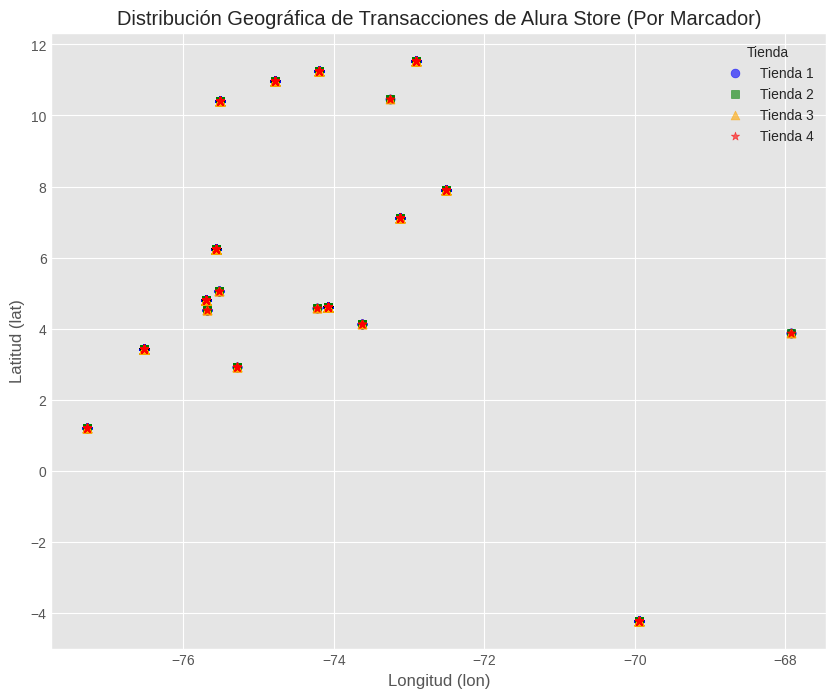

In [10]:
# --- CELDA 10: (OPTIMIZADA CON MARCADORES ÚNICOS) ---

import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 8))
plt.style.use('ggplot')

# 1. Definir un diccionario de colores y marcadores para cada tienda
estilos_tiendas = {
    'Tienda 1': {'color': 'blue', 'marker': 'o', 'label': 'Tienda 1'}, # Círculo
    'Tienda 2': {'color': 'green', 'marker': 's', 'label': 'Tienda 2'}, # Cuadrado
    'Tienda 3': {'color': 'orange', 'marker': '^', 'label': 'Tienda 3'}, # Triángulo
    'Tienda 4': {'color': 'red', 'marker': '*', 'label': 'Tienda 4'}    # Estrella
}

# 2. Iterar sobre los estilos para graficar cada tienda con su figura y color
for nombre_tienda, estilo in estilos_tiendas.items():
    # Filtrar el DataFrame para la tienda actual
    df_tienda = df_completo[df_completo['Tienda'] == nombre_tienda]

    # Graficar los puntos de esa tienda
    plt.scatter(
        x=df_tienda['lon'],
        y=df_tienda['lat'],
        s=40,             # Tamaño del punto (ajustable)
        alpha=0.6,        # Transparencia
        color=estilo['color'],
        marker=estilo['marker'], # Usamos el marcador único (o, s, ^, *)
        label=estilo['label']
    )

plt.title('Distribución Geográfica de Transacciones de Alura Store (Por Marcador)')
plt.xlabel('Longitud (lon)')
plt.ylabel('Latitud (lat)')
plt.legend(title='Tienda', loc='best')

plt.show()

# Con esta visualización, incluso si los puntos están muy juntos,
# podrás distinguir la tienda a la que pertenece cada transacción por su forma.

In [11]:
# --- CELDA 11: Rango Geográfico (Concentración) ---

# Calcular el rango (Máx - Mín) de latitud y longitud por tienda
rango_geografico = df_completo.groupby('Tienda')[['lat', 'lon']].agg(['min', 'max'])
rango_geografico['Rango Lat'] = rango_geografico['lat']['max'] - rango_geografico['lat']['min']
rango_geografico['Rango Lon'] = rango_geografico['lon']['max'] - rango_geografico['lon']['min']

print("Rango Geográfico de Ventas por Tienda (Latitud y Longitud):")
print(rango_geografico[['Rango Lat', 'Rango Lon']].sort_values(by='Rango Lat', ascending=False))

# Interpretación:
# Una tienda con rangos pequeños tiene una alta concentración de ventas en un área local.
# Una tienda con rangos grandes tiene una distribución de ventas más amplia.

# Cruza esto con el Ingreso Total:
# Si la tienda de bajos ingresos (Tu Tienda X del punto 10) tiene un rango amplio,
# podría indicar que está gastando recursos en envíos a larga distancia sin obtener grandes ganancias.

Rango Geográfico de Ventas por Tienda (Latitud y Longitud):
         Rango Lat Rango Lon
                            
Tienda                      
Tienda 1  15.75972   9.35721
Tienda 2  15.75972   9.35721
Tienda 3  15.75972   9.35721
Tienda 4  15.75972   9.35721
